In [2]:
from calendar import EPOCH
!python -m pip install --upgrade pip

In [3]:
!pip install tensorflow opencv-python matplotlib

In [2]:

import cv2
import os
import random
import numpy as np
from matplotlib import pyplot as plt # helps us visualize data

In [3]:
# import tensorflow dependencies - functional API
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten
import tensorflow as tf

In [4]:
# avoid OOM errors by setting GPU memory consumption growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [8]:
POS_PATH = os.path.join('data', 'positive')
NEG_PATH = os.path.join('data', 'negative')
ANC_PATH = os.path.join('data', 'anchor')

In [8]:
os.makedirs(POS_PATH)
os.makedirs(NEG_PATH)
os.makedirs(ANC_PATH)

FileExistsError: [WinError 183] Cannot create a file when that file already exists: 'data\\positive'

In [ ]:
import os
import shutil

# 1. Set your paths
source_dir = r'archive\lfw-deepfunneled\lfw-deepfunneled'  # Where your folders of people are
target_dir = r'data\negative'    # Where you want the images to end up

# 2. Make sure the target folder exists
os.makedirs(target_dir, exist_ok=True)

# 3. Walk through all folders and move images
count = 0
for root, dirs, files in os.walk(source_dir):
    for file in files:
        # Check if the file is an image (you can add more extensions if needed)
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            source_file = os.path.join(root, file)
            # Copy to target folder
            shutil.copy(source_file, target_dir)
            count += 1



In [5]:
# import uuid library to generate unique image names
import uuid

In [149]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    ret, frame = cap.read()

    frame = frame[120:120+250, 200:200+250, :]

    # collect anchors
    if cv2.waitKey(1) & 0XFF == ord('a'):
        imgname = os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)

    # collect positives
    if cv2.waitKey(1) & 0XFF == ord('p'):
        imgname = os.path.join(POS_PATH, '{}.jpg'.format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)

    # collect negatives
    if cv2.waitKey(1) & 0XFF == ord('p'):
        imgname = os.path.join(NEG_PATH, '{}.jpg'.format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)

    cv2.imshow('Image Collection', frame)

    if cv2.waitKey(1) & 0XFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [150]:
anchor = tf.data.Dataset.list_files(ANC_PATH+'/*.jpg').take(500)
positive = tf.data.Dataset.list_files(POS_PATH+'/*.jpg').take(500)
negative = tf.data.Dataset.list_files(NEG_PATH+'/*.jpg').take(500)

In [151]:
dir_test = anchor.as_numpy_iterator()

In [152]:
dir_test.next()

b'data\\anchor\\b0322bf5-1dc6-11f1-b18c-c4bde5e68fe2.jpg'

In [153]:
def preprocess(file_path):

    # read in image from file path
    byte_img = tf.io.read_file(file_path)
    img = tf.io.decode_jpeg(byte_img)
    img = tf.image.resize(img, (100,100))
    img = img / 255.0
    return img

In [154]:
#(anchor, positive) => 1,1,1,1,1
#(anchor, negative) => 0,0,0,0,0

In [155]:
positives = tf.data.Dataset.zip(anchor, positive, tf.data.Dataset.from_tensor_slices(tf.ones(len(anchor))))
negatives = tf.data.Dataset.zip(anchor, negative, tf.data.Dataset.from_tensor_slices(tf.zeros(len(anchor))))
data = positives.concatenate(negatives)

In [156]:
samples = data.as_numpy_iterator()

In [157]:
example = samples.next()

In [158]:
def preprocess_twin(input_img, validation_img, label):
    return (preprocess(input_img), preprocess(validation_img), label)

In [159]:
res = preprocess_twin(*example)

In [160]:
len(res)

3

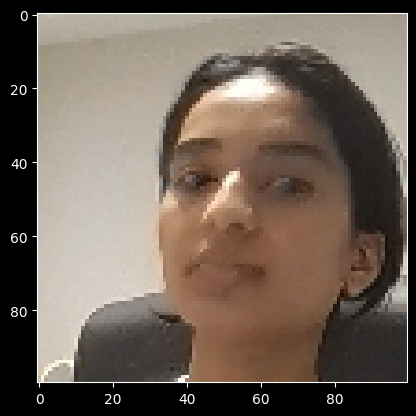

In [161]:
plt.imshow(res[1])

In [162]:
# build dataloader pipeline
data = data.map(preprocess_twin)
data = data.cache()
data = data.shuffle(buffer_size=1024)

In [163]:
# training partition
train_data = data.take(round(len(data)*.7))
train_data = train_data.batch(16)
train_data = train_data.prefetch(8)

In [164]:
train_samples = train_data.as_numpy_iterator()

In [165]:
train_sample = train_samples.next()

In [166]:
len(train_sample[0])

16

In [167]:
# testing partition
test_data = data.skip(round(len(data)*.7))
test_data = test_data.take(round(len(data)*.3))
test_data = test_data.batch(16)
test_data = test_data.prefetch(8)

In [168]:
def make_embedding():
    inp = Input(shape = (100,100,3), name = 'input_image')

    # first block
    c1 = Conv2D(64, (10,10), activation = 'relu')(inp)
    m1 = MaxPooling2D(64,(2,2), padding = 'same')(c1)

    # second block
    c2 = Conv2D(128, (7,7), activation = 'relu')(m1)
    m2 = MaxPooling2D(64,(2,2), padding = 'same')(c2)

    # third block
    c3 = Conv2D(128, (4,4), activation = 'relu')(m2)
    m3 = MaxPooling2D(64,(2,2), padding = 'same')(c3)

    # final embedding block
    c4 = Conv2D(256, (4,4), activation = 'relu')(m3)
    f1 = Flatten()(c4)
    d1 = Dense(4096, activation = 'sigmoid')(f1)

    return Model(inputs= inp, outputs=d1, name='embedding')

In [169]:
embedding = make_embedding()

In [ ]:
embedding.summary()

In [170]:
class L1Dist(Layer):
    def __init__(self, **kwargs):
        super().__init__()

    def call(self, inputs):
        input_embedding, validation_embedding = inputs
        return tf.math.abs(input_embedding-validation_embedding)



In [171]:
l1 = L1Dist()

In [172]:
input_image = Input(name='input_img', shape=(100,100,3))

In [173]:
embedding(input_image)

<KerasTensor shape=(None, 4096), dtype=float32, sparse=False, ragged=False, name=keras_tensor_115>

In [174]:
def make_siamese_model():

    # Handle inputs
    input_image = Input(name='input_img', shape=(100,100,3))

    validation_image = Input(name='validation_img', shape=(100,100,3))

    siamese_layer = L1Dist()
    siamese_layer.name = 'distance'
    distances = siamese_layer([embedding(input_image), embedding(validation_image)])

    # classification layer
    classifier  = Dense(1, activation = 'sigmoid')(distances)

    return Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork')


In [175]:
siamese_model = make_siamese_model()

In [ ]:
siamese_model.summary()

In [176]:
binary_cross_loss = tf.losses.BinaryCrossentropy()

In [177]:
opt = tf.keras.optimizers.Adam(1e-4)

In [178]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(opt=opt, siamese_model=siamese_model)

In [179]:
test_batch = train_data.as_numpy_iterator()

In [180]:
batch_1 = test_batch.next()

In [181]:
batch_1[2]

array([1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1.],
      dtype=float32)

In [186]:
@tf.function
def train_step(batch):

    # record all of our operations
    with tf.GradientTape() as tape:
        X = batch[:2]
        # get label
        y = batch[2]

        # forward pass
        yhat = siamese_model(X, training=True)
        # calculate loss
        loss = binary_cross_loss(y, yhat)
    print(loss)

    # calculate gradients
    grad = tape.gradient(loss, siamese_model.trainable_variables)

    # calculate updated weights and apply to siamese model
    opt.apply_gradients(zip(grad, siamese_model.trainable_variables))

    return loss

In [187]:
def train(data, EPOCHS):
    # loop through epochs
    for epoch in range(1, EPOCHS+1):
        print ('\n Epoch {}/{}'.format(epoch, EPOCHS))
        progbar = tf.keras.utils.Progbar(len(data))

        # loop through each batch
        for idx, batch in enumerate(data):
            # run train step here
            train_step(batch)
            progbar.update(idx+1)

        # save checkpoints
        if epoch % 10 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

In [188]:
EPOCHS = 50

In [189]:
train(train_data, EPOCHS)


 Epoch 1/50
Tensor("binary_crossentropy/div_no_nan:0", shape=(), dtype=float32)
Tensor("binary_crossentropy/div_no_nan:0", shape=(), dtype=float32)
43/44 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/stepTensor("binary_crossentropy/div_no_nan:0", shape=(), dtype=float32)
44/44 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step

 Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step

 Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step

 Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step

 Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step

 Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step

 Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 323s 7s/step

 Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step

 Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step

 Epoch 10/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step

 Epoch 11/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step

 Epoch 12/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step

 Epoch 13/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step

 Epoch 14/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step

 Epoch 15/50
44/44 ━━━

In [190]:
# import metric calculations
from tensorflow.keras.metrics import Precision, Recall

In [191]:
# get a batch of test data
test_input, test_val, y_true = test_data.as_numpy_iterator().next()

In [192]:
test_var = test_data.as_numpy_iterator().next()

In [193]:
# make predictions
y_hat = siamese_model.predict([test_input, test_val])
y_hat

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[9.99764919e-01],
       [6.14533747e-07],
       [2.19029985e-08],
       [1.10561400e-08],
       [9.96649027e-01],
       [4.32210240e-10],
       [9.99874592e-01],
       [1.92491257e-07],
       [1.00000000e+00],
       [1.00000000e+00],
       [9.99980807e-01],
       [3.67310281e-06],
       [1.99675083e-06],
       [1.00000000e+00],
       [9.99989808e-01],
       [1.18409176e-07]], dtype=float32)

In [194]:
# post processing the results
[1 if prediction > 0.5 else 0 for prediction in y_hat]

[1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0]

In [195]:
y_true

array([1., 0., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 1., 1., 0.],
      dtype=float32)

In [196]:
m = Precision()
m.update_state(y_true, y_hat)
m.result().numpy()

np.float32(1.0)

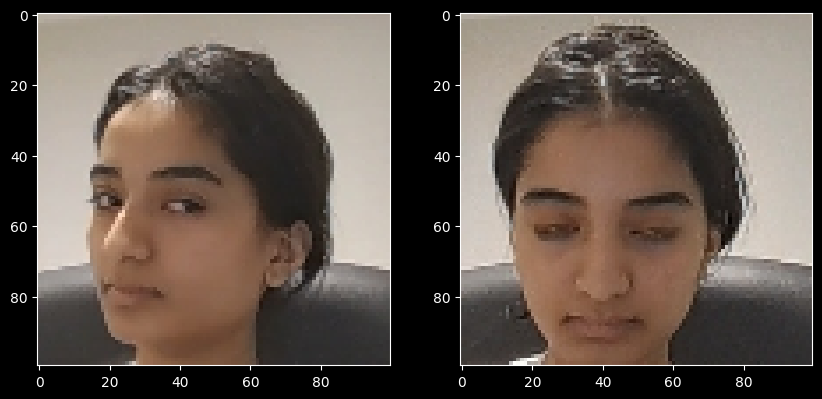

In [197]:
# set plot size
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.imshow(test_input[4])
plt.subplot(1,2,2)
plt.imshow(test_val[4])
plt.show()

In [198]:
# save weights
siamese_model.save('siamesemodel.keras')

In [199]:
# reload model
model = tf.keras.models.load_model('siamesemodel.keras', custom_objects={'L1Dist': L1Dist, 'BinaryCrossentropy': tf.losses.BinaryCrossentropy})

In [200]:
model.predict([test_input, test_val])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 855ms/step


array([[9.99764919e-01],
       [6.14533747e-07],
       [2.19029985e-08],
       [1.10561400e-08],
       [9.96649027e-01],
       [4.32210240e-10],
       [9.99874592e-01],
       [1.92491257e-07],
       [1.00000000e+00],
       [1.00000000e+00],
       [9.99980807e-01],
       [3.67310281e-06],
       [1.99675083e-06],
       [1.00000000e+00],
       [9.99989808e-01],
       [1.18409176e-07]], dtype=float32)

In [201]:
model.summary()

Model: "SiameseNetwork"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_img           │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ validation_img      │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4096)      │ 38,960,448 │ input_img[0][0],  │
│ (Functional)        │                   │            │ validation_img[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l1_dist_11 (L1Dist) │ (None, 4096)      │          0 │ embedding[0][0],  │
│                     │                   │            │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │      4,097 │ l1_dist_11[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,964,545 (148.64 MB)

 Trainable params: 38,964,545 (148.64 MB)

 Non-trainable params: 0 (0.00 B)

In [203]:
for image in os.listdir(os.path.join('application_data', 'verification_images')):
    validation_img = os.path.join('application_data', 'verification_images', image)
    print(validation_img)

application_data\verification_images\00026c0f-1d13-11f1-8403-c4bde5e68fe2 - Copy - Copy (2).jpg
application_data\verification_images\000e908a-1d13-11f1-aa02-c4bde5e68fe2 - Copy.jpg
application_data\verification_images\000e908a-1d13-11f1-aa02-c4bde5e68fe2.jpg
application_data\verification_images\002afda6-1d13-11f1-90a6-c4bde5e68fe2 - Copy.jpg
application_data\verification_images\00524219-1d13-11f1-9cda-c4bde5e68fe2.jpg
application_data\verification_images\007d112f-1d13-11f1-b40d-c4bde5e68fe2 - Copy - Copy (2).jpg
application_data\verification_images\00a1241f-1d13-11f1-87cc-c4bde5e68fe2 - Copy (2).jpg
application_data\verification_images\00a1241f-1d13-11f1-87cc-c4bde5e68fe2 - Copy.jpg
application_data\verification_images\00d6103f-1d13-11f1-868e-c4bde5e68fe2.jpg
application_data\verification_images\00f37749-1d13-11f1-a2e6-c4bde5e68fe2 - Copy.jpg
application_data\verification_images\00fd3729-1d13-11f1-98be-c4bde5e68fe2 - Copy.jpg
application_data\verification_images\02c22064-1d13-11f1-a0e1

In [204]:
def verify(model, detection_threshold, verification_threshold):
    results = []
    for image in os.listdir(os.path.join('application_data', 'verification_images')):
        input_img = preprocess(os.path.join('application_data', 'input_image', 'input_image.jpg'))
        validation_img = preprocess(os.path.join('application_data', 'verification_images', image))

        result = model.predict(list(np.expand_dims([input_img, validation_img], axis=1)))
        results.append(result)

    detection = np.sum(np.array(results) > detection_threshold)
    verification = detection / len(os.listdir(os.path.join('application_data', 'verification_images')))
    verified = verification > verification_threshold

    return results, verified

In [206]:
import cv2
import os
cap = cv2.VideoCapture(0)
while cap.isOpened():
    ret, frame = cap.read()
    frame = frame[120:120+250, 200:200+250, :]

    cv2.imshow('Verification', frame)

    # verification trigger
    if cv2.waitKey(10) & 0xFF == ord('v'):
        # save input image to application_data/input_image folder
        cv2.imwrite(os.path.join('application_data', 'input_image', 'input_image.jpg'), frame)
        # run verification
        results, verified = verify(model, 0.9, 0.7)
        print(verified)

    if cv2.waitKey(10) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1